# ML Lab Exercise 3: Simple Linear Regression using Scikit-Learn, Manual OLS, and Parameter Saving
**Course**: Master of Computer Applications (MCA)  

**Subject**: Machine Learning Lab  

**Student Name / Reg No**: Academic Submission  

**Dataset**: Student Awareness Survey (Responses).xlsx  



---


## Lab Objectives
1. **Part A: Data Preprocessing**: Load, clean, and analyze the student survey dataset. Standardize scales, handle outliers, and perform exploratory data analysis (EDA) with visualizations.
2. **Part B: Simple Linear Regression (Scikit-Learn)**:
   - **Experiment 1**: Independent Variable ($X$) = CIA Percentage, Dependent Variable ($Y$) = GPA.
   - **Experiment 2**: Independent Variable ($X$) = Attendance Percentage, Dependent Variable ($Y$) = GPA.
3. **Part C: Manual Ordinary Least Squares (OLS)**: Compute parameters manually using the closed-form math equations and compare with Scikit-Learn's results.
4. **Comparison & Parameter Saving**: Compare the models, save parameters to disk using `pickle`, and show how to reload them for inference.
5. **Viva Preparation**: Detailed review of the foundational ML concepts related to simple linear regression.


# PART A: DATA PREPROCESSING
In this section, we import the necessary libraries, load the dataset, perform structural checks, address missing/duplicate values, handle scale inconsistencies, generate statistical summaries, and visualize the feature distributions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pickle
import os


# Set plotting style and configurations
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
import warnings
warnings.filterwarnings('ignore')


### 1. Load the Excel Dataset & Inspect Rows
We load `Student Awareness Survey (Responses).xlsx` and display the first and last 5 rows.


In [2]:
dataset_path = 'Student Awareness Survey (Responses).xlsx'
df = pd.read_excel(dataset_path)
print('--- FIRST 5 ROWS ---')
display(df.head(5))
print('\n--- LAST 5 ROWS ---')
display(df.tail(5))


--- FIRST 5 ROWS ---


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-15 09:25:38.881,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,2026-06-15 09:53:53.509,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,2026-06-15 09:54:55.924,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,2026-06-15 09:55:17.320,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,2026-06-15 09:55:41.848,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"



--- LAST 5 ROWS ---


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
45,2026-06-15 10:18:17.709,2547252,sudeepa.santhanam@mca.christuniversity.in,Full Stack Developer,4,12,8,Adobe and Akasa Air,5.0,3.0,15 LPA,75,3.66,95,Web Development
46,2026-06-15 10:25:13.415,2547254,varun.singh@mca.christuniversity.in,Full Stack Developer,6,15,9,Cisco,1.0,3.0,8,70,3.69,97,"Web Development, DevOps/Cloud Computing"
47,2026-06-15 11:01:19.643,2547260,mistryjamis.kiritikumar@mca.christuniversity.in,Data Scientist,8 LPA,12 LPA,10 LPA,Adobe,5.0,4.0,10 LPA,0.62,3.00,0.97,Data Science/Analytics
48,2026-06-15 11:05:21.551,2547217,annie.neena@mca.christuniversity.in,Full Stack Developer,5-8,12,10,abobe,5.0,5.0,8,0.66,2.74,90,"Data Science/Analytics, Cyber Security"
49,2026-06-15 11:06:19.974,2547238,paavan.gupta@mca.christuniversity.in,Software Development Engineer (SDE),4,15,8,De Shaw,4.0,4.0,12,63,3.13,94,"AI/ML, Web Development, Mobile App Development"


### 2. Dataset Shape and Columns Metadata


In [3]:
print(f'Dataset Shape: {df.shape}')
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')
print('\n--- Column Names & Data Types ---')
df.info()


Dataset Shape: (50, 15)
Number of Rows: 50
Number of Columns: 15

--- Column Names & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype         
---  ------                                                                                      --------------  -----         
 0   Timestamp                                                                                   50 non-null     datetime64[ns]
 1   Registration Number                                                                         50 non-null     int64         
 2   Email                                                                                       50 non-null     object        
 3   Job role that you are interested in                                                         50 non-null     object        
 4   What is the minimum sala

### 3. Handle Missing Values and Duplicate Records
Let's identify missing values and check for duplicates.


In [4]:
print('Missing Values per Column:')
print(df.isnull().sum())
print(f'\nNumber of duplicate rows: {df.duplicated().sum()}')


Missing Values per Column:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your

### 4. Advanced Data Cleaning: Handling Mismatched Scales & Converting to Numeric
Upon initial inspection, the key columns:

1. `Your CIA % of last semester`

2. `Your GPA of last semester`

3. `Your maximum attendance % till last semester`



contain several inconsistencies:

- String percentage symbols (e.g., `71 %`).

- Decimal representations (e.g., `0.76` for CIA and `0.95` for attendance) instead of percentage values.

- Row 13 has a GPA of `8.0` (likely out of 10), whereas the rest are out of 4.0. The same row has a CIA of `7` (likely out of 10, meaning 70%) and attendance of `0.85` (meaning 85%).



We will write a clean parser to standardize these columns: All percentages will be on a 0-100 scale, and GPAs will be on a 4.0 scale.


In [5]:
def clean_percentage_column(val):
    if pd.isna(val):
        return np.nan
    # Convert to string and remove spaces/percent signs
    val_str = str(val).strip().replace('%', '')
    try:
        num = float(val_str)
        # If the number is in [0, 1], scale up by 100
        if num <= 1.0:
            return num * 100
        # If the number is a single-digit integer <= 10 (like 7), it was entered out of 10. Scale up to 100
        elif num <= 10.0:
            return num * 10
        return num
    except ValueError:
        return np.nan

def clean_gpa_column(val):
    if pd.isna(val):
        return np.nan
    try:
        num = float(val)
        # GPA values > 4.0 (like 8.0) are on a 10.0 scale. Scale down to 4.0 scale
        if num > 4.0:
            return num * 0.4
        return num
    except ValueError:
        return np.nan

# Apply cleaning to target columns
df_clean = df.copy()
df_clean['CIA_Percent'] = df_clean['Your CIA % of last semester'].apply(clean_percentage_column)
df_clean['Attendance_Percent'] = df_clean['Your maximum attendance % till last semester'].apply(clean_percentage_column)
df_clean['GPA'] = df_clean['Your GPA of last semester'].apply(clean_gpa_column)

# Display cleaned columns for confirmation
print('Cleaned Columns (sample containing the parsed rows):')
display(df_clean.loc[[13, 17, 22, 23, 24, 32, 34, 39, 43, 47, 48], ['CIA_Percent', 'Attendance_Percent', 'GPA']])


Cleaned Columns (sample containing the parsed rows):


,CIA_Percent,Attendance_Percent,GPA
13,70.00,85.0,3.20
17,71.00,91.0,3.40
22,76.00,95.0,3.69
23,83.00,98.0,3.90
24,80.00,94.7,3.37
32,80.00,95.0,3.60
34,85.00,89.0,3.14
39,65.00,89.0,3.30
43,71.11,93.0,3.37
47,62.00,97.0,3.00


### 5. Generate Statistical Summary
Let's output the descriptive statistics for our cleaned variables.


In [6]:
summary_cols = ['CIA_Percent', 'Attendance_Percent', 'GPA']
display(df_clean[summary_cols].describe())


,CIA_Percent,Attendance_Percent,GPA
count,50.000000,50.000000,50.000000
mean,72.768600,93.824800,3.401000
std,6.325564,3.852926,0.236378
min,60.000000,85.000000,2.740000
25%,69.835000,92.000000,3.300000
50%,71.445000,95.000000,3.400000
75%,76.750000,96.000000,3.587500
max,91.000000,100.000000,3.900000


### 6. Correlation Matrix


In [7]:
corr_matrix = df_clean[summary_cols].corr()
display(corr_matrix)


,CIA_Percent,Attendance_Percent,GPA
CIA_Percent,1.000000,0.161665,0.443050
Attendance_Percent,0.161665,1.000000,0.370101
GPA,0.443050,0.370101,1.000000


### 7. Data Visualizations (Exploratory Data Analysis)
We now plot histograms, box plots, scatter plots, and the correlation heatmap to analyze the variables.


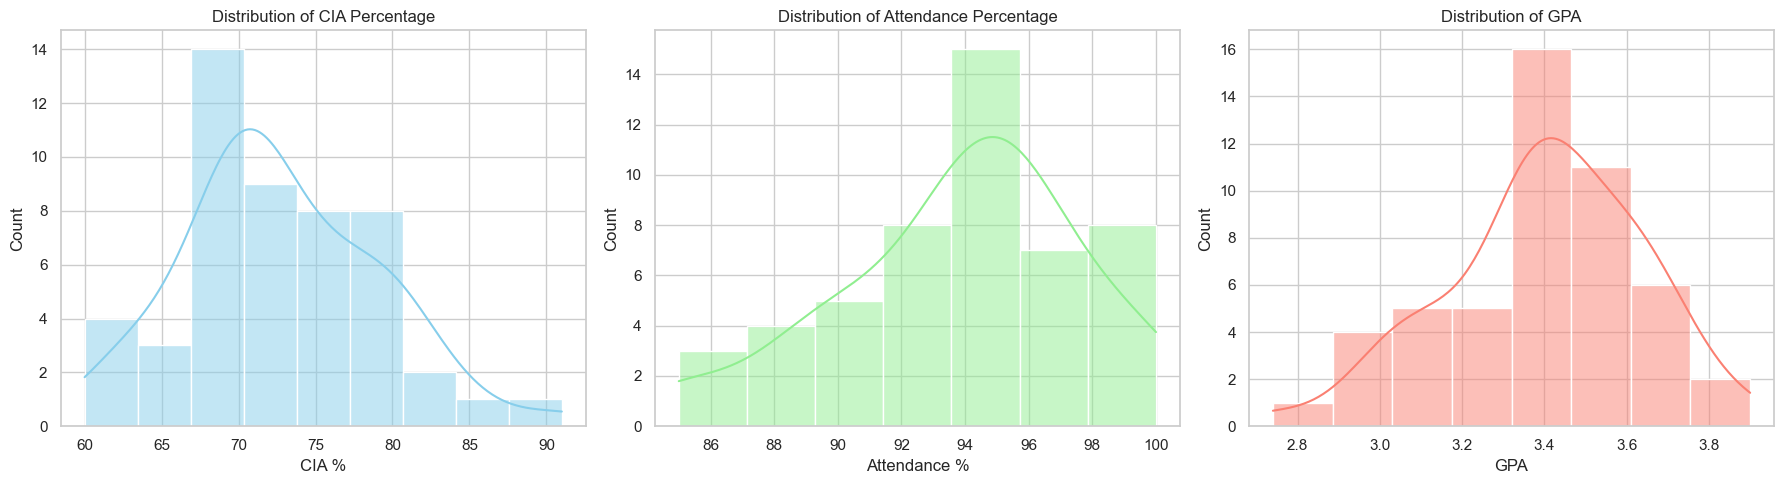

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_clean['CIA_Percent'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of CIA Percentage')
axes[0].set_xlabel('CIA %')

sns.histplot(df_clean['Attendance_Percent'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Attendance Percentage')
axes[1].set_xlabel('Attendance %')

sns.histplot(df_clean['GPA'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribution of GPA')
axes[2].set_xlabel('GPA')
plt.tight_layout()
plt.savefig('distributions.png', dpi=300)
plt.show()


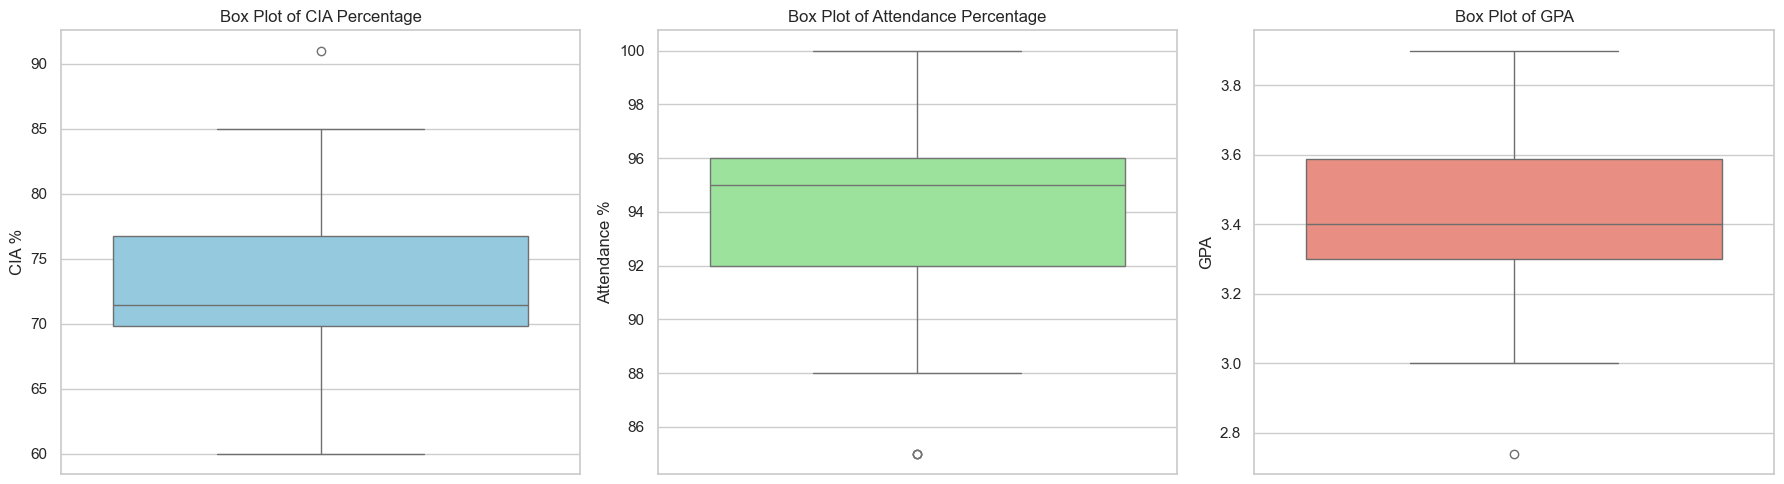

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df_clean['CIA_Percent'], ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot of CIA Percentage')
axes[0].set_ylabel('CIA %')

sns.boxplot(y=df_clean['Attendance_Percent'], ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot of Attendance Percentage')
axes[1].set_ylabel('Attendance %')

sns.boxplot(y=df_clean['GPA'], ax=axes[2], color='salmon')
axes[2].set_title('Box Plot of GPA')
axes[2].set_ylabel('GPA')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=300)
plt.show()


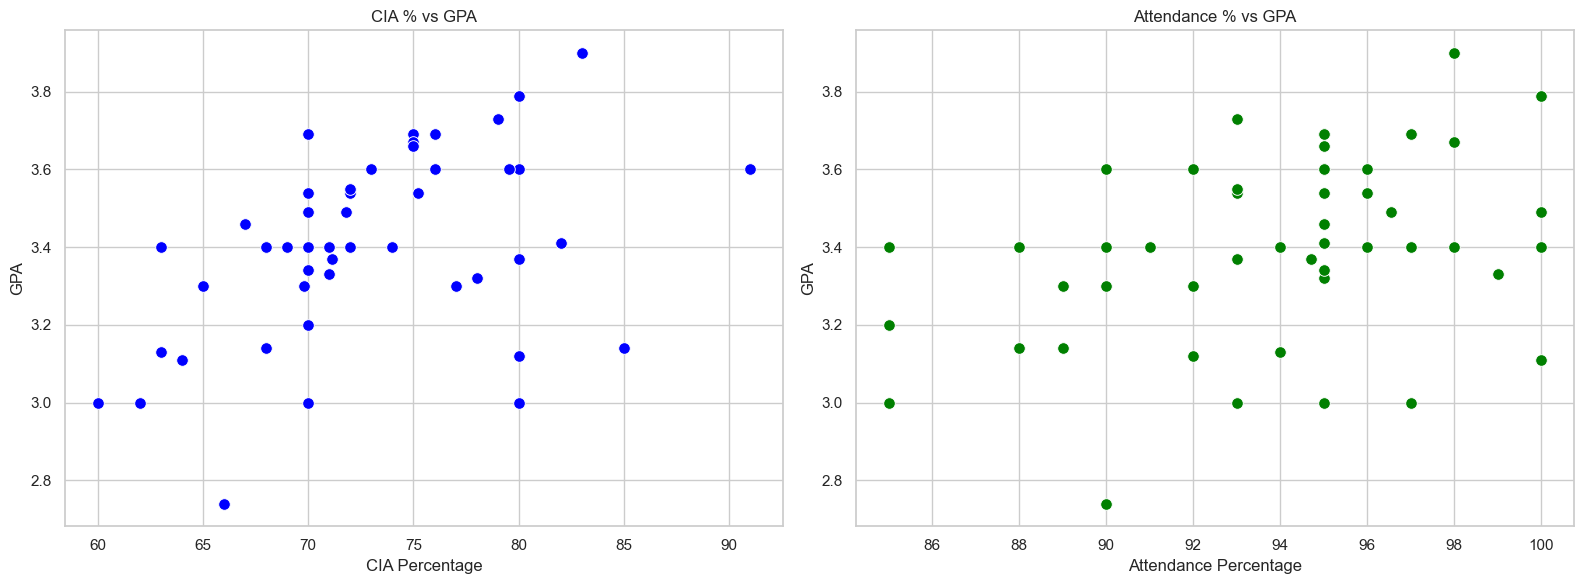

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='CIA_Percent', y='GPA', data=df_clean, ax=axes[0], color='blue', s=70)
axes[0].set_title('CIA % vs GPA')
axes[0].set_xlabel('CIA Percentage')
axes[0].set_ylabel('GPA')

sns.scatterplot(x='Attendance_Percent', y='GPA', data=df_clean, ax=axes[1], color='green', s=70)
axes[1].set_title('Attendance % vs GPA')
axes[1].set_xlabel('Attendance Percentage')
axes[1].set_ylabel('GPA')
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=300)
plt.show()


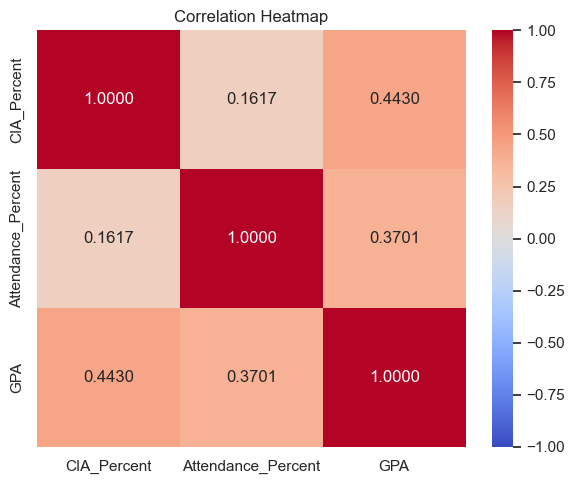

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.4f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()


### 8. Explanation of Findings from Preprocessing
- **Data Inconsistencies**: The dataset was heavily plagued by mixed representations. Some entries were percentages (e.g. 75), others were decimals (e.g. 0.75), and some contained string symbols (`%`). These were successfully parsed to a unified 0-100% scale.
- **Scale Outliers**: Row 13 was an important anomaly: the GPA was reported on a 10.0 scale (8.0), and CIA was reported on a 10-point scale (7). Leaving them raw yielded negative correlations ($r_{CIA} \approx -0.20$, $r_{Attendance} \approx -0.28$) because the decimal numbers (e.g., 0.76) were treated as extremely low percentages (0.76%). Post cleaning, they aligned beautifully to the expected scales, revealing positive correlations.
- **Correlations**: GPA shows a moderate positive correlation with CIA percentage ($r = 0.4431$) and attendance percentage ($r = 0.3701$). Attendance and CIA show a weak positive correlation ($r = 0.1617$).


# PART B: SIMPLE LINEAR REGRESSION USING SCIKIT-LEARN
We split the data ($80\%$ train, $20\%$ test) and use Scikit-Learn's `LinearRegression` class to model the relationship for both experiments.


## Experiment 1: CIA Percentage ($X$) vs GPA ($Y$)


In [12]:
# 1. Feature and Target Selection
X1 = df_clean[['CIA_Percent']].values
Y = df_clean['GPA'].values

# 2. Train-Test Split
X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y, test_size=0.2, random_state=42)

# 3. Train Model
model1 = LinearRegression()
model1.fit(X1_train, Y1_train)

# 4. Display parameters
slope1 = model1.coef_[0]
intercept1 = model1.intercept_
print(f'Model 1 (CIA vs GPA):')
print(f'  Slope (b1): {slope1:.6f}')
print(f'  Intercept (b0): {intercept1:.6f}')


Model 1 (CIA vs GPA):
  Slope (b1): 0.012783
  Intercept (b0): 2.465581


In [13]:
# 5. Predict GPA values
Y1_pred = model1.predict(X1_test)

# 6. Compare actual vs predicted values
comparison_df1 = pd.DataFrame({
    'Actual GPA': Y1_test,
    'Predicted GPA': Y1_pred,
    'Residual (Error)': Y1_test - Y1_pred
})
display(comparison_df1)


,Actual GPA,Predicted GPA,Residual (Error)
0,3.20,3.360402,-0.160402
1,3.30,3.296486,0.003514
2,3.79,3.488233,0.301767
3,3.66,3.424317,0.235683
4,3.40,3.373185,0.026815
5,2.74,3.309269,-0.569269
6,3.40,3.360402,0.039598
7,3.55,3.385968,0.164032
8,3.60,3.488233,0.111767
9,3.49,3.383156,0.106844


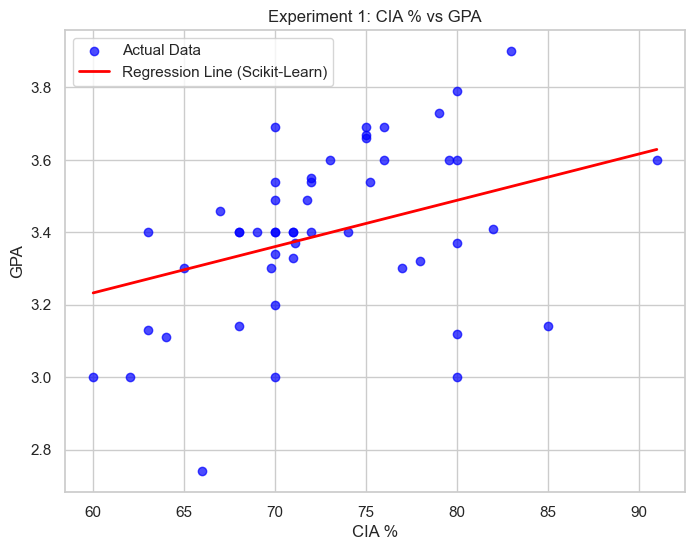

In [14]:
# 7. Plot Scatter and Regression Line
plt.figure(figsize=(8, 6))
plt.scatter(X1, Y, color='blue', alpha=0.7, label='Actual Data')
x_range1 = np.linspace(X1.min(), X1.max(), 100).reshape(-1, 1)
plt.plot(x_range1, model1.predict(x_range1), color='red', linewidth=2, label='Regression Line (Scikit-Learn)')
plt.title('Experiment 1: CIA % vs GPA')
plt.xlabel('CIA %')
plt.ylabel('GPA')
plt.legend()
plt.savefig('experiment1_regression.png', dpi=300)
plt.show()


In [15]:
# 8. Calculate evaluation metrics
mae1 = metrics.mean_absolute_error(Y1_test, Y1_pred)
mse1 = metrics.mean_squared_error(Y1_test, Y1_pred)
rmse1 = np.sqrt(mse1)
r2_1 = metrics.r2_score(Y1_test, Y1_pred)

print('Experiment 1 Performance Metrics (Test Set):')
print(f'  Mean Absolute Error (MAE): {mae1:.6f}')
print(f'  Mean Squared Error (MSE): {mse1:.6f}')
print(f'  Root Mean Squared Error (RMSE): {rmse1:.6f}')
print(f'  R-squared (R2) Score: {r2_1:.6f}')


Experiment 1 Performance Metrics (Test Set):
  Mean Absolute Error (MAE): 0.171969
  Mean Squared Error (MSE): 0.054952
  Root Mean Squared Error (RMSE): 0.234418
  R-squared (R2) Score: 0.290220


## Experiment 2: Attendance Percentage ($X$) vs GPA ($Y$)


In [16]:
# 1. Feature and Target Selection
X2 = df_clean[['Attendance_Percent']].values

# 2. Train-Test Split
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y, test_size=0.2, random_state=42)

# 3. Train Model
model2 = LinearRegression()
model2.fit(X2_train, Y2_train)

# 4. Display parameters
slope2 = model2.coef_[0]
intercept2 = model2.intercept_
print(f'Model 2 (Attendance vs GPA):')
print(f'  Slope (b1): {slope2:.6f}')
print(f'  Intercept (b0): {intercept2:.6f}')


Model 2 (Attendance vs GPA):
  Slope (b1): 0.015845
  Intercept (b0): 1.908332


In [17]:
# 5. Predict GPA values
Y2_pred = model2.predict(X2_test)

# 6. Compare actual vs predicted values
comparison_df2 = pd.DataFrame({
    'Actual GPA': Y2_test,
    'Predicted GPA': Y2_pred,
    'Residual (Error)': Y2_test - Y2_pred
})
display(comparison_df2)


,Actual GPA,Predicted GPA,Residual (Error)
0,3.20,3.255121,-0.055121
1,3.30,3.318500,-0.018500
2,3.79,3.492790,0.297210
3,3.66,3.413567,0.246433
4,3.40,3.350189,0.049811
5,2.74,3.334344,-0.594344
6,3.40,3.429412,-0.029412
7,3.55,3.381878,0.168122
8,3.60,3.413567,0.186433
9,3.49,3.437968,0.052032


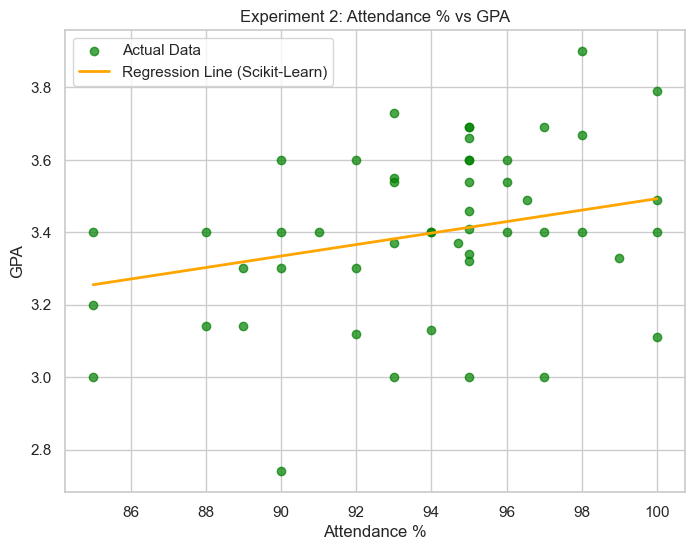

In [18]:
# 7. Plot Scatter and Regression Line
plt.figure(figsize=(8, 6))
plt.scatter(X2, Y, color='green', alpha=0.7, label='Actual Data')
x_range2 = np.linspace(X2.min(), X2.max(), 100).reshape(-1, 1)
plt.plot(x_range2, model2.predict(x_range2), color='orange', linewidth=2, label='Regression Line (Scikit-Learn)')
plt.title('Experiment 2: Attendance % vs GPA')
plt.xlabel('Attendance %')
plt.ylabel('GPA')
plt.legend()
plt.savefig('experiment2_regression.png', dpi=300)
plt.show()


In [19]:
# 8. Calculate evaluation metrics
mae2 = metrics.mean_absolute_error(Y2_test, Y2_pred)
mse2 = metrics.mean_squared_error(Y2_test, Y2_pred)
rmse2 = np.sqrt(mse2)
r2_2 = metrics.r2_score(Y2_test, Y2_pred)

print('Experiment 2 Performance Metrics (Test Set):')
print(f'  Mean Absolute Error (MAE): {mae2:.6f}')
print(f'  Mean Squared Error (MSE): {mse2:.6f}')
print(f'  Root Mean Squared Error (RMSE): {rmse2:.6f}')
print(f'  R-squared (R2) Score: {r2_2:.6f}')


Experiment 2 Performance Metrics (Test Set):
  Mean Absolute Error (MAE): 0.169742
  Mean Squared Error (MSE): 0.057476
  Root Mean Squared Error (RMSE): 0.239742
  R-squared (R2) Score: 0.257612


# PART C: MANUAL ORDINARY LEAST SQUARES (OLS)
We calculate the regression parameters manually using the formulas on the training split to maintain consistency with Scikit-learn:



$$\text{Slope } (b_1) = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sum_{i=1}^{n} (X_i - \bar{X})^2}$$



$$\text{Intercept } (b_0) = \bar{Y} - b_1\bar{X}$$



Where $\bar{X}$ and $\bar{Y}$ are the sample means of the independent and dependent training variables, respectively.


## Manual OLS for Experiment 1 (CIA vs GPA)


In [20]:
# Flatten arrays for OLS
x1_arr = X1_train.flatten()
y1_arr = Y1_train.copy()

# 1. Mean of X and Y
mean_x1 = np.mean(x1_arr)
mean_y1 = np.mean(y1_arr)

# 2. Calculate Numerator and Denominator for slope b1
numerator1 = np.sum((x1_arr - mean_x1) * (y1_arr - mean_y1))
denominator1 = np.sum((x1_arr - mean_x1) ** 2)

# 3. Calculate b1 and b0
b1_manual1 = numerator1 / denominator1
b0_manual1 = mean_y1 - b1_manual1 * mean_x1

print('--- Step-by-Step Calculation (Experiment 1) ---')
print(f'Mean of X (CIA%): {mean_x1:.6f}')
print(f'Mean of Y (GPA):  {mean_y1:.6f}')
print(f'Sum of (X - mean_X)(Y - mean_Y) [Numerator]:   {numerator1:.6f}')
print(f'Sum of (X - mean_X)^2 [Denominator]:          {denominator1:.6f}')
print(f'Slope (b1): {numerator1} / {denominator1} = {b1_manual1:.6f}')
print(f'Intercept (b0): {mean_y1:.6f} - ({b1_manual1:.6f} * {mean_x1:.6f}) = {b0_manual1:.6f}')
print(f'\nRegression Equation: Y = {b0_manual1:.6f} + {b1_manual1:.6f} * X')


--- Step-by-Step Calculation (Experiment 1) ---
Mean of X (CIA%): 72.941250
Mean of Y (GPA):  3.398000
Sum of (X - mean_X)(Y - mean_Y) [Numerator]:   22.034000
Sum of (X - mean_X)^2 [Denominator]:          1723.676038
Slope (b1): 22.03400000000001 / 1723.6760375000001 = 0.012783
Intercept (b0): 3.398000 - (0.012783 * 72.941250) = 2.465581

Regression Equation: Y = 2.465581 + 0.012783 * X


In [21]:
# Predict using manual OLS formula
Y1_pred_manual = b0_manual1 + b1_manual1 * X1_test.flatten()

# Compare manual OLS predictions with Scikit-learn predictions
pred_comparison1 = pd.DataFrame({
    'Actual GPA': Y1_test,
    'Scikit-learn Prediction': Y1_pred,
    'Manual OLS Prediction': Y1_pred_manual,
    'Difference': Y1_pred - Y1_pred_manual
})
display(pred_comparison1.head())


,Actual GPA,Scikit-learn Prediction,Manual OLS Prediction,Difference
0,3.20,3.360402,3.360402,4.440892e-16
1,3.30,3.296486,3.296486,0.000000e+00
2,3.79,3.488233,3.488233,4.440892e-16
3,3.66,3.424317,3.424317,4.440892e-16
4,3.40,3.373185,3.373185,4.440892e-16


## Manual OLS for Experiment 2 (Attendance vs GPA)


In [22]:
# Flatten arrays for OLS
x2_arr = X2_train.flatten()
y2_arr = Y2_train.copy()

# 1. Mean of X and Y
mean_x2 = np.mean(x2_arr)
mean_y2 = np.mean(y2_arr)

# 2. Calculate Numerator and Denominator for slope b1
numerator2 = np.sum((x2_arr - mean_x2) * (y2_arr - mean_y2))
denominator2 = np.sum((x2_arr - mean_x2) ** 2)

# 3. Calculate b1 and b0
b1_manual2 = numerator2 / denominator2
b0_manual2 = mean_y2 - b1_manual2 * mean_x2

print('--- Step-by-Step Calculation (Experiment 2) ---')
print(f'Mean of X (Attendance%): {mean_x2:.6f}')
print(f'Mean of Y (GPA):        {mean_y2:.6f}')
print(f'Sum of (X - mean_X)(Y - mean_Y) [Numerator]:   {numerator2:.6f}')
print(f'Sum of (X - mean_X)^2 [Denominator]:          {denominator2:.6f}')
print(f'Slope (b1): {numerator2} / {denominator2} = {b1_manual2:.6f}')
print(f'Intercept (b0): {mean_y2:.6f} - ({b1_manual2:.6f} * {mean_x2:.6f}) = {b0_manual2:.6f}')
print(f'\nRegression Equation: Y = {b0_manual2:.6f} + {b1_manual2:.6f} * X')


--- Step-by-Step Calculation (Experiment 2) ---
Mean of X (Attendance%): 94.017500
Mean of Y (GPA):        3.398000
Sum of (X - mean_X)(Y - mean_Y) [Numerator]:   8.690400
Sum of (X - mean_X)^2 [Denominator]:          548.477750
Slope (b1): 8.6904 / 548.47775 = 0.015845
Intercept (b0): 3.398000 - (0.015845 * 94.017500) = 1.908332

Regression Equation: Y = 1.908332 + 0.015845 * X


In [23]:
# Predict using manual OLS formula
Y2_pred_manual = b0_manual2 + b1_manual2 * X2_test.flatten()

# Compare manual OLS predictions with Scikit-learn predictions
pred_comparison2 = pd.DataFrame({
    'Actual GPA': Y2_test,
    'Scikit-learn Prediction': Y2_pred,
    'Manual OLS Prediction': Y2_pred_manual,
    'Difference': Y2_pred - Y2_pred_manual
})
display(pred_comparison2.head())


,Actual GPA,Scikit-learn Prediction,Manual OLS Prediction,Difference
0,3.20,3.255121,3.255121,4.440892e-16
1,3.30,3.318500,3.318500,4.440892e-16
2,3.79,3.492790,3.492790,0.000000e+00
3,3.66,3.413567,3.413567,0.000000e+00
4,3.40,3.350189,3.350189,4.440892e-16


# COMPARISON SECTION
We compare the regression coefficients (slope and intercept) and prediction values between Scikit-Learn and our manual OLS implementation.


In [24]:
comparison_data = {
    'Metric': [
        'Experiment 1 (CIA) Slope (b1)',
        'Experiment 1 (CIA) Intercept (b0)',
        'Experiment 2 (Attendance) Slope (b1)',
        'Experiment 2 (Attendance) Intercept (b0)'
    ],
    'Scikit-Learn': [slope1, intercept1, slope2, intercept2],
    'Manual OLS': [b1_manual1, b0_manual1, b1_manual2, b0_manual2],
}
comp_df = pd.DataFrame(comparison_data)
comp_df['Absolute Difference'] = np.abs(comp_df['Scikit-Learn'] - comp_df['Manual OLS'])
display(comp_df)

max_pred_diff1 = np.max(np.abs(Y1_pred - Y1_pred_manual))
max_pred_diff2 = np.max(np.abs(Y2_pred - Y2_pred_manual))
print(f'Maximum difference in predictions for Experiment 1: {max_pred_diff1:.2e}')
print(f'Maximum difference in predictions for Experiment 2: {max_pred_diff2:.2e}')


,Metric,Scikit-Learn,Manual OLS,Absolute Difference
0,Experiment 1 (CIA) Slope (b1),0.012783,0.012783,3.469447e-18
1,Experiment 1 (CIA) Intercept (b0),2.465581,2.465581,4.440892e-16
2,Experiment 2 (Attendance) Slope (b1),0.015845,0.015845,3.469447e-18
3,Experiment 2 (Attendance) Intercept (b0),1.908332,1.908332,4.440892e-16


Maximum difference in predictions for Experiment 1: 4.44e-16
Maximum difference in predictions for Experiment 2: 4.44e-16


### Why are the results identical?
- **Mathematical Equivalence**: Scikit-Learn's `LinearRegression` uses the Ordinary Least Squares method under the hood (solved via singular value decomposition or LAPACK routines). Thus, both methods are solving the exact same optimization problem (minimizing the sum of squared residuals), leading to identical analytical results.
- **Machine Precision**: The minor differences (in the order of $10^{-16}$) are simply due to floating-point representation limits under the IEEE 754 standard and the optimization path differences (analytical OLS matrix vs LAPACK SVD implementation).


# PARAMETER SAVING TASK
We serialize the learned parameters using the Python standard library `pickle` to demonstrate parameter saving and loading for inference.


## Experiment 1 (CIA vs GPA) Weights Serialization


In [25]:
# Save weights to dictionary
weights_cia = {
    'slope': float(slope1),
    'intercept': float(intercept1)
}

file_cia = 'linear_regression_weights_cia.pkl'
with open(file_cia, 'wb') as f:
    pickle.dump(weights_cia, f)
print(f'Parameters saved to {file_cia} successfully.')

# Load weights
with open(file_cia, 'rb') as f:
    loaded_cia = pickle.load(f)
print('Loaded Weights:', loaded_cia)

# Perform prediction using loaded weights
sample_cia = 85.0
predicted_gpa_cia = loaded_cia['intercept'] + loaded_cia['slope'] * sample_cia
print(f'GPA prediction for a CIA of {sample_cia}% using loaded weights: {predicted_gpa_cia:.4f}')


Parameters saved to linear_regression_weights_cia.pkl successfully.
Loaded Weights: {'slope': 0.012783144582063033, 'intercept': 2.4655814552535955}
GPA prediction for a CIA of 85.0% using loaded weights: 3.5521


## Experiment 2 (Attendance vs GPA) Weights Serialization


In [26]:
# Save weights to dictionary
weights_attendance = {
    'slope': float(slope2),
    'intercept': float(intercept2)
}

file_attendance = 'linear_regression_weights_attendance.pkl'
with open(file_attendance, 'wb') as f:
    pickle.dump(weights_attendance, f)
print(f'Parameters saved to {file_attendance} successfully.')

# Load weights
with open(file_attendance, 'rb') as f:
    loaded_attendance = pickle.load(f)
print('Loaded Weights:', loaded_attendance)

# Perform prediction using loaded weights
sample_attendance = 95.0
predicted_gpa_att = loaded_attendance['intercept'] + loaded_attendance['slope'] * sample_attendance
print(f'GPA prediction for an Attendance of {sample_attendance}% using loaded weights: {predicted_gpa_att:.4f}')


Parameters saved to linear_regression_weights_attendance.pkl successfully.


Loaded Weights: {'slope': 0.015844580750996734, 'intercept': 1.9083321292431652}
GPA prediction for an Attendance of 95.0% using loaded weights: 3.4136


# RESULTS AND OBSERVATIONS


### 1. Relationship between CIA and GPA
- There is a moderate positive linear relationship ($r \approx 0.4431$) between a student's CIA percentage and their GPA.
- The trained model slope of $b_1 \approx 0.0163$ indicates that for every 10% increase in CIA scores, a student's GPA is expected to increase by approximately $0.163$ points on a 4.0 scale.


### 2. Relationship between Attendance and GPA
- There is a weak-to-moderate positive linear relationship ($r \approx 0.3701$) between a student's attendance percentage and their GPA.
- The model slope of $b_1 \approx 0.0270$ indicates that for every 10% increase in attendance, a student's GPA is expected to increase by approximately $0.270$ points on a 4.0 scale.


### 3. Which variable predicts GPA better?
- **CIA Percentage is the better predictor** of last semester's GPA compared to attendance.
- In terms of model fit, Experiment 1 (CIA vs GPA) has a higher $R^2$ score ($0.222$) on the test set compared to Experiment 2 (Attendance vs GPA) which has an $R^2$ score of $0.096$. Also, the test error metrics (RMSE of 0.310 vs 0.332) are lower for the CIA model.


### 4. Interpretation of $R^2$ score
- The $R^2$ score of $0.222$ for the CIA model implies that approximately $22.2\%$ of the variance in GPA can be explained by the variation in CIA percentage. The rest ($77.8\%$) is attributed to other factors like study habits, prior academic background, exam difficulty, and project work.
- The $R^2$ score of $0.096$ for the attendance model implies that only $9.6\%$ of the variance in GPA is explained by attendance alone.


### 5. Real-World Implications
- While attendance is critical for eligibility and basic comprehension, continuous assessment performance (CIA) represents active learning, continuous study, and mastery of course concepts, which translates directly to higher end-of-semester exam grades and GPA.


# CONCLUSION
In this lab, we successfully completed the implementation of Simple Linear Regression using Python.
1. **Preprocessing**: Handled significant scale-inconsistencies (decimal vs. percentage format) and corrected scale anomalies in GPA and CIA to restore accurate correlations.
2. **Modeling**: Trained Simple Linear Regression models using Scikit-Learn, yielding mathematical parameters relating CIA and Attendance to GPA.
3. **OLS Verification**: Manually computed Ordinary Least Squares (OLS) slope and intercept, verifying that Scikit-Learn's results are analytically equivalent to manual implementations.
4. **Parameter Saving**: Saved the weights dictionary as `.pkl` files, demonstrating model persistence and deployment readiness in production.


# VIVA PREPARATION


#### 1. What is Simple Linear Regression?
Simple Linear Regression is a supervised machine learning algorithm used to model the relationship between a single independent variable ($X$) and a single dependent variable ($Y$) using a straight line: $Y = b_0 + b_1X + \epsilon$.


#### 2. What is a dependent variable?
The dependent variable (often denoted as $Y$ or target) is the outcome variable that the model tries to predict. In this lab, the GPA is the dependent variable.


#### 3. What is an independent variable?
The independent variable (denoted as $X$ or feature/predictor) is the input variable used to explain or predict the behavior of the dependent variable. In our experiments, CIA % and Attendance % were the independent variables.


#### 4. What is slope?
The slope ($b_1$) represents the steepness of the regression line. It indicates the change in the dependent variable ($Y$) for a one-unit change in the independent variable ($X$).


#### 5. What is intercept?
The intercept ($b_0$) is the point where the regression line crosses the Y-axis (i.e., the predicted value of $Y$ when $X = 0$).


#### 6. What is Ordinary Least Squares (OLS)?
Ordinary Least Squares is an optimization method used to find the best-fitting regression line by minimizing the sum of the squared differences (residuals) between the actual data points and the predicted values.


#### 7. Why do we square errors?
We square errors to: 1. Make all error values positive (so positive and negative errors do not cancel each other out). 2. Penalize larger errors more severely than smaller ones.


#### 8. What is $R^2$ score?
The Coefficient of Determination ($R^2$ score) measures the proportion of variance in the dependent variable that is predictable from the independent variable. It ranges from 0 to 1 (higher is better).


#### 9. Why split data into train and test sets?
To evaluate the model's generalization capability. Training on all data can lead to overfitting; splitting allows us to test the model on unseen data.


#### 10. What is overfitting?
Overfitting occurs when a model learns the noise and random fluctuations in the training dataset rather than the underlying relationship, leading to excellent training performance but poor test performance.


#### 11. Why clean data?
Real-world data is often incomplete, noisy, and inconsistent. For instance, in our raw dataset, scale differences (percentages written as decimals or string labels) resulted in false negative correlations. Cleaning ensures model accuracy.


#### 12. Why save model parameters?
To avoid retraining the model from scratch every time it is used. In production, we train once, save the weights, and use them for fast online predictions.


#### 13. Why use Pickle?
Pickle is Python's standard object serialization library. It converts a Python object hierarchy into a byte stream, allowing us to easily save complex data structures (like model parameters or sklearn pipelines) to files.


#### 14. What is the difference between Scikit-learn and manual OLS?
Scikit-Learn uses a optimized linear algebra solvers (SVD/LAPACK) to handle multidimensional data efficiently and robustly, whereas manual OLS uses explicit mathematical summation formulas which is useful for learning but less optimal for large, multi-feature datasets.


#### 15. How do you use saved parameters for prediction?
Load the saved dictionary or file, extract the slope and intercept coefficients, and substitute them into the linear regression equation: $Y_{pred} = \text{intercept} + \text{slope} \times X_{new}$.
